# Surface textures

***

`tostada.GaussianRandomFunction.py` can be used to realize 2D random fields $X(x,y)$ where $X$ can be intepreted as varying height of a surface texture as a function of position.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost
from tostada.GaussianRandomFunction import generate_grf
import tostada.Statistics as stats

In [76]:
BoxSize = [5,5,0]
gaussian_field = generate_grf(max_dist=BoxSize, #Spatial extent for the field
                  dx = 0.01, #resolution of the field
                  correlation_length=0.6, #correlation length of spatial features in the texture
                  param=[1.3],
                  is_3D=False) #since a surface texture only depends on x and y.

(500, 500)


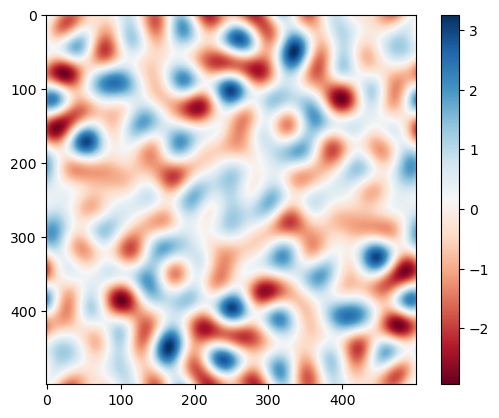

In [77]:
plt.imshow(gaussian_field ,cmap='RdBu') 
plt.colorbar()

Since the gaussian random fields are generated using FFTs, they naturally obey periodic boundary conditions (also applicable to the microstructures made thereof).

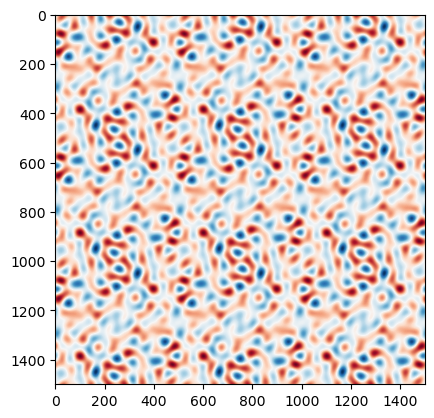

In [78]:
plt.imshow(np.tile(gaussian_field,[3,3]),cmap='RdBu')

The gaussian random field X generated in _tostada_ always has mean 0 and standard deviation 1 ($<X>=0$, $\sigma_{X}=1$).

In [ ]:
np.std(gaussian_field),np.mean(gaussian_field) 

(np.float64(1.0), np.float64(-1.637090463191271e-17))

One can scale X to have prescribed heights in microns.

In [80]:
h_max = 0.2 # maximum above and below (in microns)
gaussian_field = (gaussian_field - np.min(gaussian_field)) * (2 * h_max) / (np.max(gaussian_field) - np.min(gaussian_field)) - h_max

In [81]:
np.std(gaussian_field),np.mean(gaussian_field),np.max(gaussian_field),np.min(gaussian_field) 

(np.float64(0.06455972803691928),
 np.float64(-0.010278441626007051),
 np.float64(0.20000000000000007),
 np.float64(-0.2))

The resulting height profile can be visualized using _pyvista_ pre-installed with the base packages of _tostada_.

In [103]:
x,y = np.meshgrid(np.linspace(-BoxSize[0]/2,BoxSize[0]/2,gaussian_field.shape[0]),np.linspace(-BoxSize[0]/2,BoxSize[0]/2,gaussian_field.shape[1]))

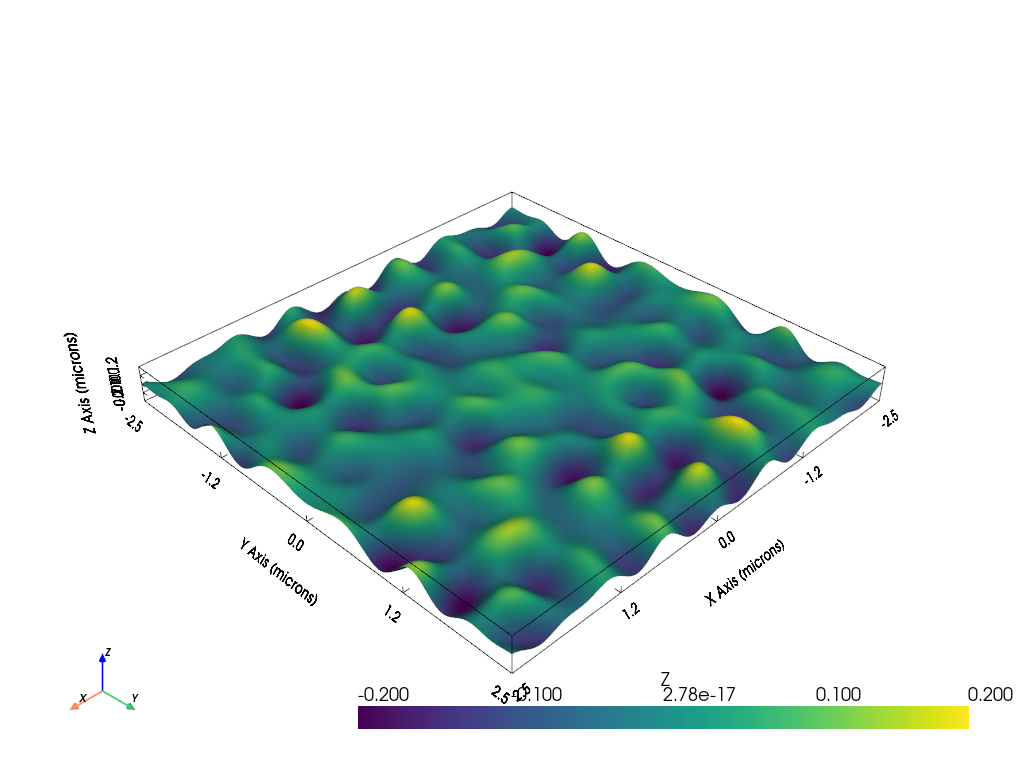

In [104]:
import pyvista as pv
pv.set_jupyter_backend("static")
grid = pv.StructuredGrid(x,y,gaussian_field)
grid.points = np.c_[x.ravel(), y.ravel(), gaussian_field.ravel()]
grid.dimensions = x.shape[0], x.shape[1], 1  # dimensions should match the array shape

# Step 2: Add Z as a scalar field to plot contours or colors
grid["Z"] = gaussian_field.ravel()

# Step 3: Plot
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="Z", cmap="viridis", show_edges=False)
plotter.show_axes()
plotter.add_axes()
plotter.show_bounds(
    #grid='front',            # show grid on front face (optional)
    xtitle='X Axis (microns)',
    ytitle='Y Axis (microns)',
    ztitle='Z Axis (microns)',
    location='outer',        # labels outside the plot
    all_edges=True,          # draw all edges
    font_size=12,
)
plotter.show()

This gaussian random field can also be specified as a `PhaseDistribution` to access it's statistical properties.

In [ ]:
X = tost.PhaseDistribution(gaussian_field,resolution=0.01)

(500, 500) (500, 500)


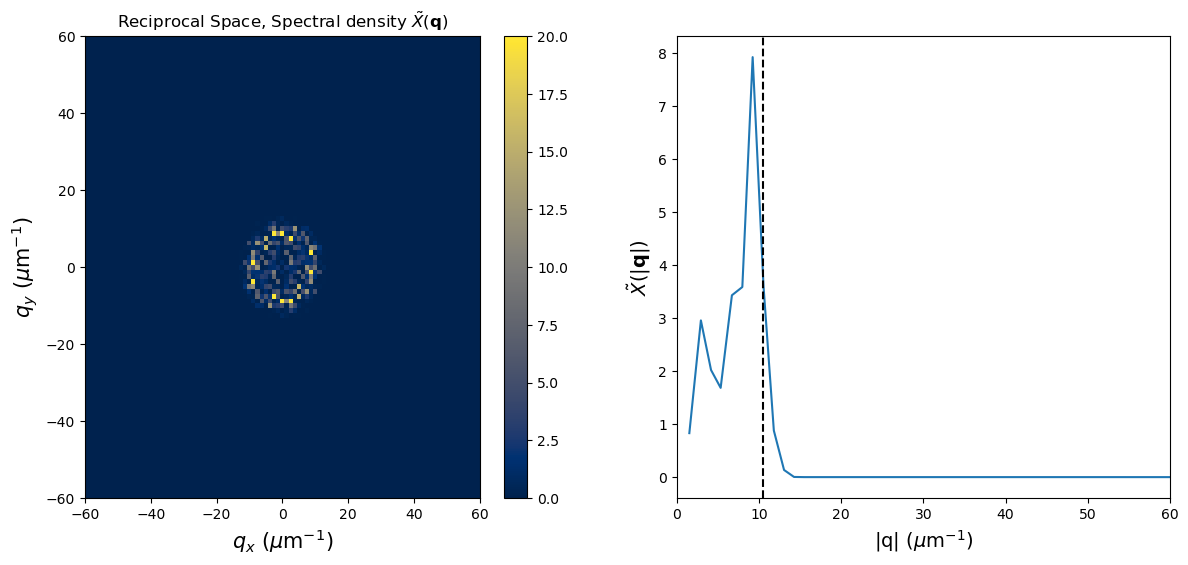

In [ ]:
fig = tost.Visualize(X)

ax = fig.plot_reciprocal_space()
ax[1].axvline(x=2*np.pi/0.6,linestyle='--',color='black')
